In [19]:
from langgraph.graph import StateGraph, START,END 
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Literal
from dotenv import load_dotenv
from math import sqrt

In [20]:
load_dotenv()
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [21]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    eq: str
    d: int
    result: str

In [22]:
graph = StateGraph(QuadState)

In [23]:
def show_equation(state: QuadState) -> QuadState: 
    a = state["a"]
    b = state["b"]
    c = state["c"]
    state["eq"] = f"{a}X^2 + {b}X + {c}"

    return state

In [24]:
def calc_d(state: QuadState) -> QuadState:
    a = state["a"]
    b = state["b"]
    c = state["c"]

    state["d"] = b**2 - (4*a*c)
    
    return state

In [25]:
def real_roots(state: QuadState) -> QuadState:
    a = state["a"]
    b = state["b"]
    d = state["d"]

    root1 = (-b + sqrt(d))/2*a
    root2 = (-b - sqrt(d))/2*a

    result = f"Root1 = {str(root1)}, Root2 = {str(root2)}"
    state["result"] = result 

    return state


In [26]:
def same_roots(state: QuadState) -> QuadState:
    a = state["a"]
    b = state["b"]
    
    root = (-b)/2*a

    result = f"D = 0 => Same Roots. Root = {str(root)}"
    state["result"] = result 

    return state


In [27]:
def no_roots(state: QuadState) -> QuadState:
    result = f"D < 0 => No real roots"
    state["result"] = result 

    return state


In [28]:
def conditional(state: QuadState) -> Literal["real_roots","same_roots","no_roots"]:
    if state["d"] < 0:
        return "no_roots"
    elif state["d"] == 0:
        return "same_roots"
    else:
        return "real_roots"

In [29]:
graph.add_node("show_equation",show_equation)
graph.add_node("calc_d",calc_d)
graph.add_node("real_roots",real_roots)
graph.add_node("same_roots",same_roots)
graph.add_node("no_roots",no_roots)

In [30]:
graph.add_edge(START,"show_equation")
graph.add_edge("show_equation","calc_d")
graph.add_conditional_edges("calc_d",conditional)
graph.add_edge("real_roots",END)
graph.add_edge("same_roots",END)
graph.add_edge("no_roots",END)

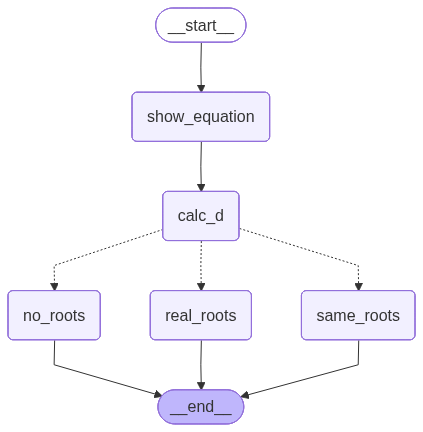

In [32]:
workflow = graph.compile()
workflow

In [37]:
initial_state = {
    "a": 4,
    "b": -5,
    "c": -4
}

final_state = workflow.invoke(initial_state)

In [38]:
final_state

{'a': 4,
 'b': -5,
 'c': -4,
 'eq': '4X^2 + -5X + -4',
 'd': 89,
 'result': 'Root1 = 28.867962264113206, Root2 = -8.867962264113206'}